# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

 # **1. Sumber Dataset**

**Dataset**: Wine Quality (Red Wine) dari UCI Machine Learning Repository

**Sumber**: https://archive.ics.uci.edu/ml/datasets/wine+quality

**Deskripsi**: Dataset ini berisi informasi fisikokimia dari varian red wine Portugal ("Vinho Verde"). Setiap sampel memiliki 11 fitur input dan 1 variabel target (quality score 0-10).

**Fitur Input**:
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol

**Target**: quality (akan dikonversi menjadi binary: Good >= 7, Bad < 7)

**Jumlah Data**: 1599 sampel


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.2.2
Numpy version: 2.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Memuat dataset
# Jika di Google Colab, upload file terlebih dahulu
# Jika di lokal, sesuaikan path

# Download langsung dari UCI Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'\nKolom: {df.columns.tolist()}')

Dataset berhasil dimuat!
Jumlah baris: 1599
Jumlah kolom: 12

Kolom: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [ ]:
# Melihat 5 baris pertama dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Melihat info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# Statistik deskriptif
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# 4.1 Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


In [ ]:
# 4.2 Cek Data Duplikat
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
print(f'Persentase duplikat: {(duplicates/len(df))*100:.2f}%')

Jumlah data duplikat: 240
Persentase duplikat: 15.01%


=== Distribusi Quality ===
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


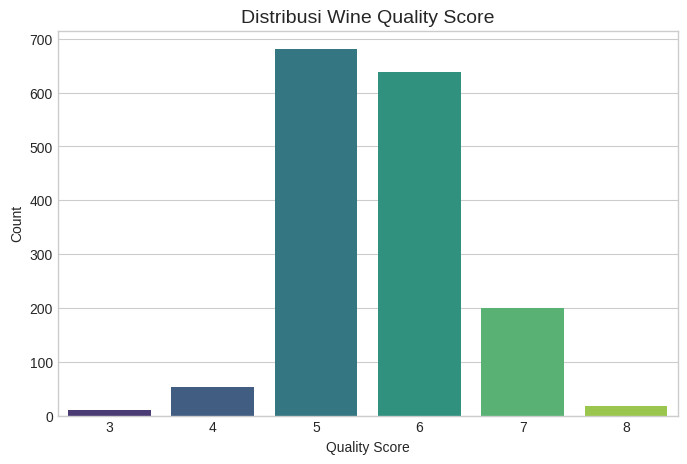

In [ ]:
# 4.3 Distribusi Target Variable (quality)
print('=== Distribusi Quality ===')
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribusi Wine Quality Score', fontsize=14)
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

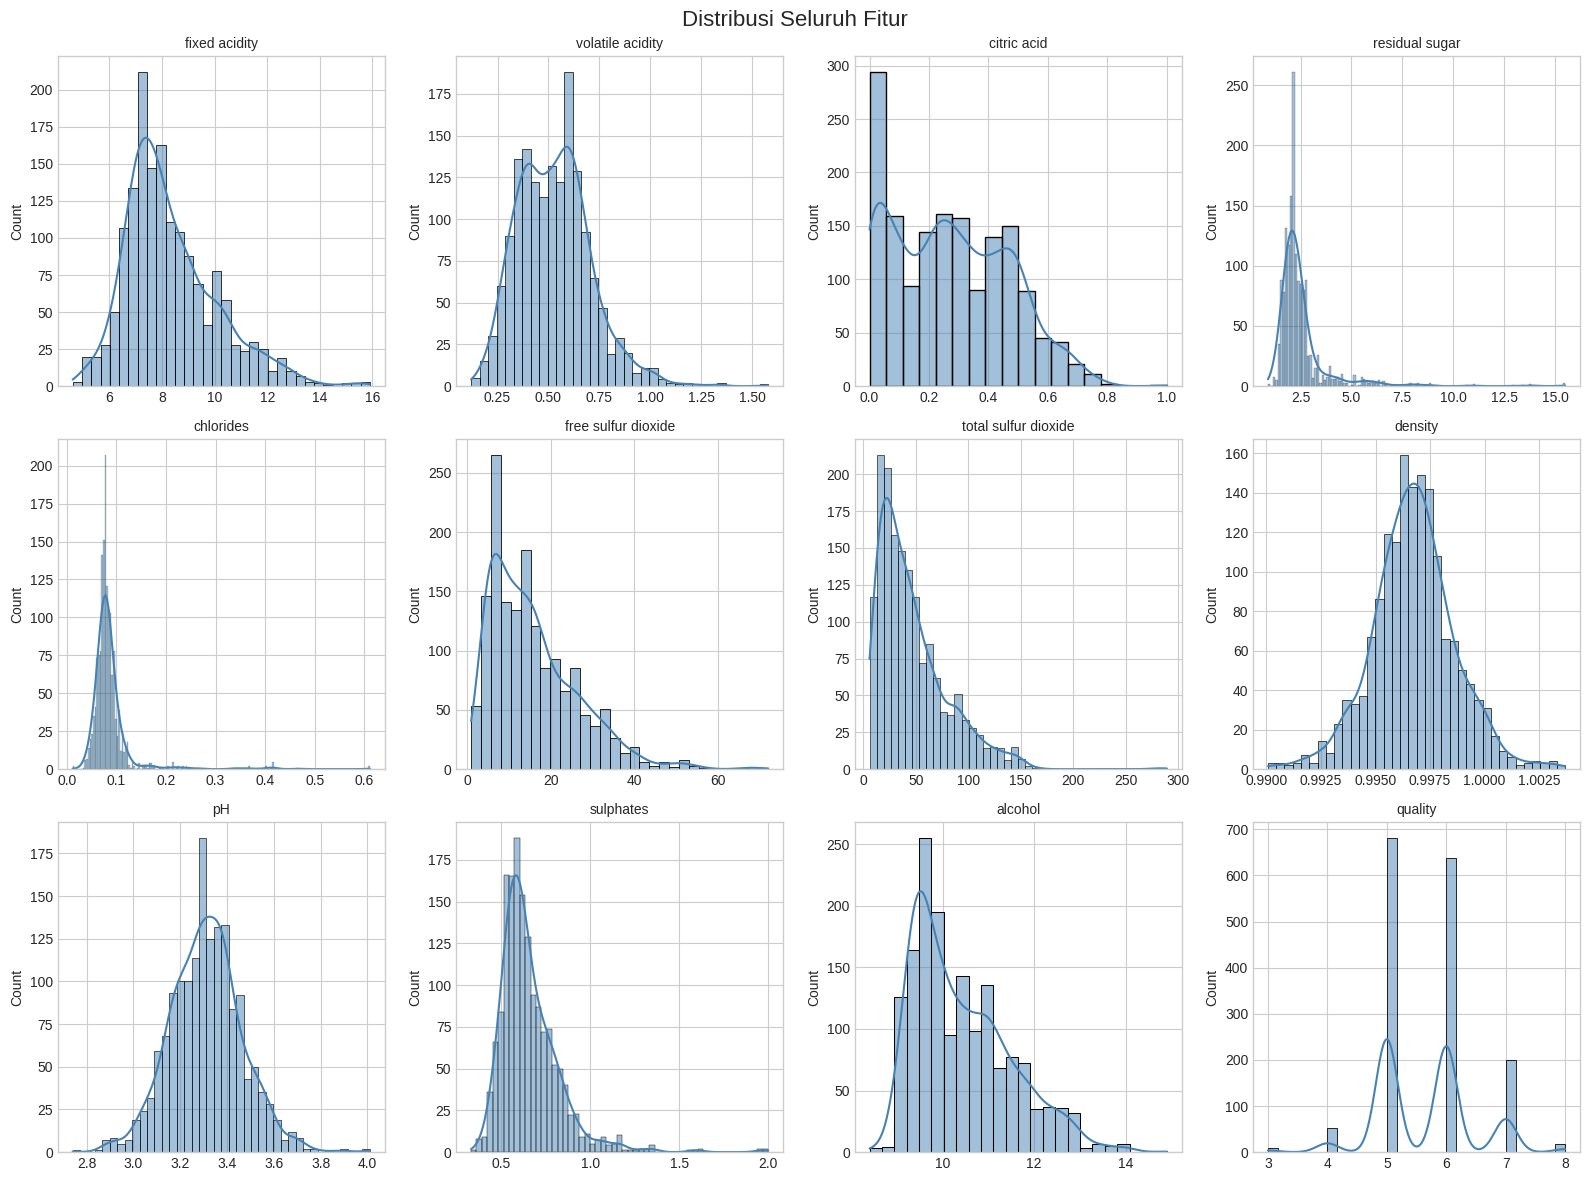

In [ ]:
# 4.4 Distribusi seluruh fitur
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Distribusi Seluruh Fitur', fontsize=16)

for idx, col in enumerate(df.columns):
    ax = axes[idx // 4, idx % 4]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

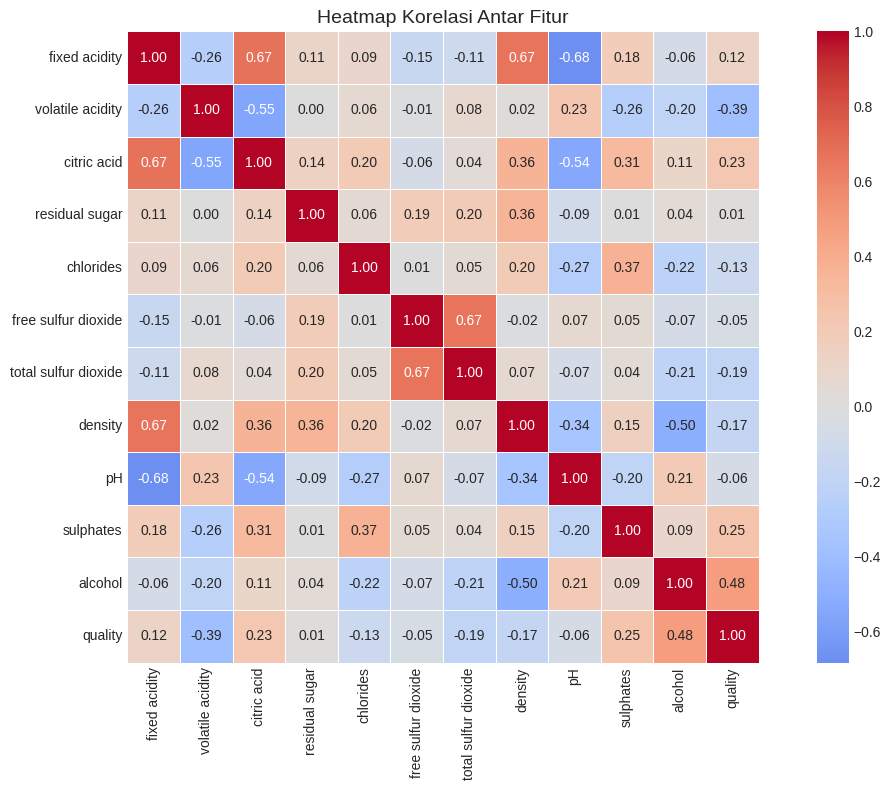

In [ ]:
# 4.5 Heatmap Korelasi
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

=== Korelasi dengan Quality ===
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


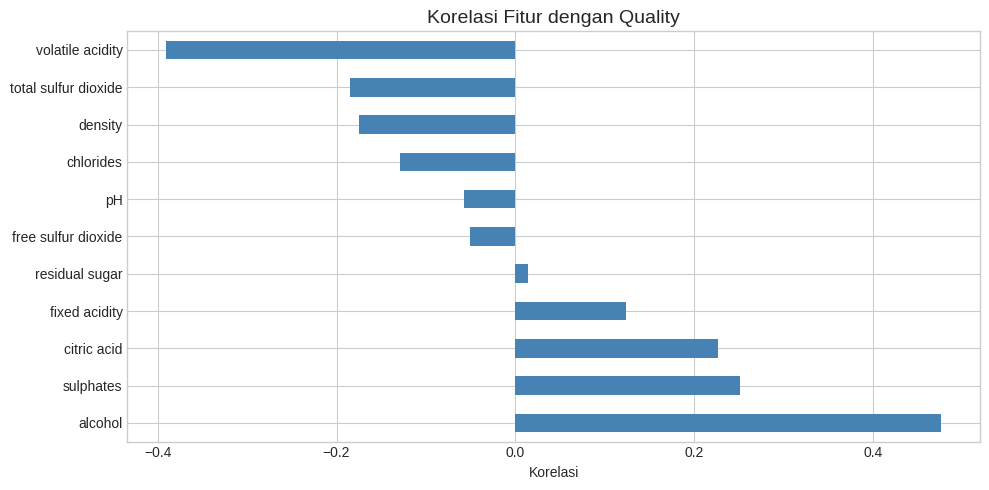

In [ ]:
# 4.6 Korelasi fitur dengan target (quality)
corr_target = df.corr(numeric_only=True)['quality'].drop('quality').sort_values(ascending=False)
print('=== Korelasi dengan Quality ===')
print(corr_target)

plt.figure(figsize=(10, 5))
corr_target.plot(kind='barh', color='steelblue')
plt.title('Korelasi Fitur dengan Quality', fontsize=14)
plt.xlabel('Korelasi')
plt.tight_layout()
plt.show()

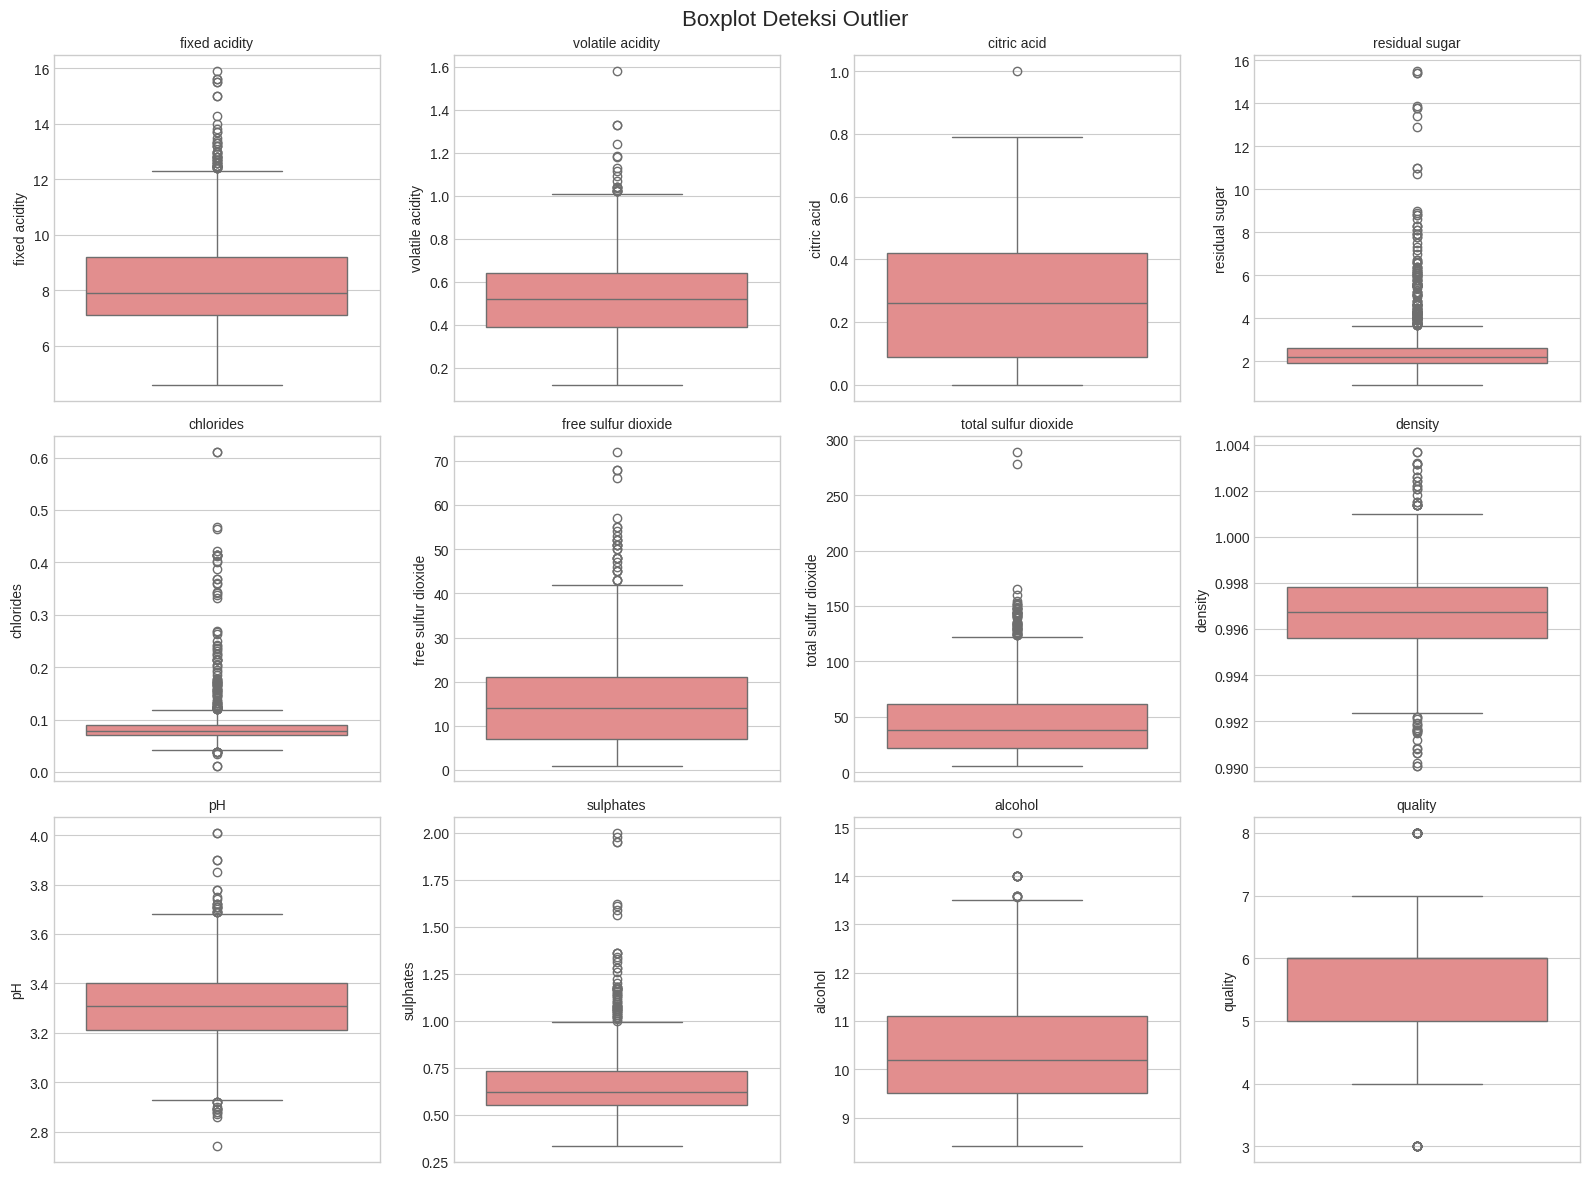

In [ ]:
# 4.7 Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Boxplot Deteksi Outlier', fontsize=16)

for idx, col in enumerate(df.columns):
    ax = axes[idx // 4, idx % 4]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# 5.1 Hapus data duplikat
df_clean = df.copy()
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Hapus duplikat: {before} -> {after} ({before - after} baris dihapus)')

Hapus duplikat: 1599 -> 1359 (240 baris dihapus)


In [ ]:
# 5.2 Handle missing values
missing_count = df_clean.isnull().sum().sum()
print(f'Total missing values: {missing_count}')

if missing_count > 0:
    df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)
    print('Missing values telah diisi dengan median')
else:
    print('Tidak ada missing values - data bersih!')

Total missing values: 0
Tidak ada missing values - data bersih!


=== Distribusi Target (Binary) ===
quality_label
0    1175
1     184
Name: count, dtype: int64

Persentase Good Wine: 13.54%


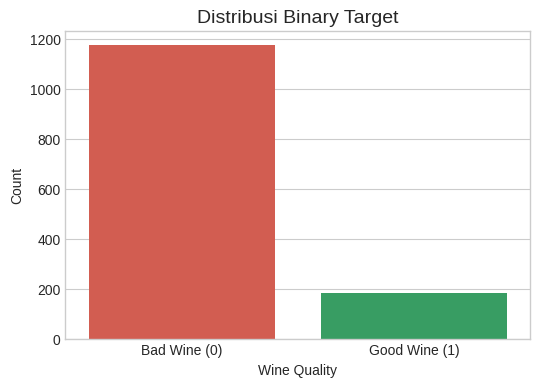

In [ ]:
# 5.3 Konversi target ke binary classification
# quality >= 7 : Good Wine (1)
# quality < 7  : Bad Wine (0)
df_clean['quality_label'] = (df_clean['quality'] >= 7).astype(int)

print('=== Distribusi Target (Binary) ===')
print(df_clean['quality_label'].value_counts())
print(f'\nPersentase Good Wine: {(df_clean["quality_label"].mean())*100:.2f}%')

plt.figure(figsize=(6, 4))
sns.countplot(x='quality_label', data=df_clean, palette=['#e74c3c', '#27ae60'])
plt.title('Distribusi Binary Target', fontsize=14)
plt.xticks([0, 1], ['Bad Wine (0)', 'Good Wine (1)'])
plt.xlabel('Wine Quality')
plt.ylabel('Count')
plt.show()

In [ ]:
# 5.4 Deteksi dan penanganan outlier menggunakan IQR
feature_cols = df_clean.columns.drop(['quality', 'quality_label'])
outliers_removed = 0

for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before_count = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    removed = before_count - len(df_clean)
    outliers_removed += removed
    if removed > 0:
        print(f'  {col}: {removed} outlier dihapus')

print(f'\nTotal outlier dihapus: {outliers_removed}')
print(f'Sisa data: {len(df_clean)} baris')

  fixed acidity: 41 outlier dihapus
  volatile acidity: 19 outlier dihapus
  citric acid: 1 outlier dihapus
  residual sugar: 112 outlier dihapus
  chlorides: 73 outlier dihapus
  free sulfur dioxide: 23 outlier dihapus
  total sulfur dioxide: 44 outlier dihapus
  density: 20 outlier dihapus
  pH: 16 outlier dihapus
  sulphates: 23 outlier dihapus
  alcohol: 2 outlier dihapus

Total outlier dihapus: 374
Sisa data: 985 baris


In [ ]:
# 5.5 Pisahkan features dan target
X = df_clean.drop(columns=['quality', 'quality_label'])
y = df_clean['quality_label']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:\n{y.value_counts()}')

Features shape: (985, 11)
Target shape: (985,)

Target distribution:
quality_label
0    860
1    125
Name: count, dtype: int64


In [ ]:
# 5.6 Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: X={X_train.shape}, y={y_train.shape}')
print(f'Test set: X={X_test.shape}, y={y_test.shape}')
print(f'\nDistribusi target (train): {y_train.value_counts().to_dict()}')
print(f'Distribusi target (test): {y_test.value_counts().to_dict()}')

Training set: X=(788, 11), y=(788,)
Test set: X=(197, 11), y=(197,)

Distribusi target (train): {0: 688, 1: 100}
Distribusi target (test): {0: 172, 1: 25}


In [ ]:
# 5.7 Feature Scaling (StandardScaler)
scaler = StandardScaler()
feature_names = X_train.columns.tolist()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)

print('Feature scaling (StandardScaler) berhasil diterapkan!')
print(f'\nMean (train, sebelum): {X_train.mean().mean():.4f}')
print(f'Mean (train, sesudah): {X_train_scaled.mean().mean():.4f}')
print(f'Std  (train, sesudah): {X_train_scaled.std().mean():.4f}')

Feature scaling (StandardScaler) berhasil diterapkan!

Mean (train, sebelum): 7.4477
Mean (train, sesudah): 0.0000
Std  (train, sesudah): 1.0006


In [ ]:
# 5.8 Simpan hasil preprocessing
import os

output_dir = 'winequality_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train_scaled.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test_scaled.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

print(f'Data preprocessing berhasil disimpan di folder: {output_dir}/')
print(f'  - X_train.csv: {X_train_scaled.shape}')
print(f'  - X_test.csv: {X_test_scaled.shape}')
print(f'  - y_train.csv: {y_train.shape}')
print(f'  - y_test.csv: {y_test.shape}')

Data preprocessing berhasil disimpan di folder: winequality_preprocessing/
  - X_train.csv: (788, 11)
  - X_test.csv: (197, 11)
  - y_train.csv: (788,)
  - y_test.csv: (197,)


In [ ]:
# Verifikasi data tersimpan dengan benar
X_train_check = pd.read_csv(os.path.join(output_dir, 'X_train.csv'))
X_test_check = pd.read_csv(os.path.join(output_dir, 'X_test.csv'))
y_train_check = pd.read_csv(os.path.join(output_dir, 'y_train.csv'))
y_test_check = pd.read_csv(os.path.join(output_dir, 'y_test.csv'))

print('=== Verifikasi Data Preprocessed ===')
print(f'X_train: {X_train_check.shape}')
print(f'X_test: {X_test_check.shape}')
print(f'y_train: {y_train_check.shape}')
print(f'y_test: {y_test_check.shape}')
print(f'\nX_train (5 baris pertama):')
print(X_train_check.head())
print(f'\nData siap untuk tahap modelling!')

=== Verifikasi Data Preprocessed ===
X_train: (788, 11)
X_test: (197, 11)
y_train: (788, 1)
y_test: (197, 1)

X_train (5 baris pertama):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.858157          0.644666    -1.324933        0.460364  -0.161988   
1       1.253352         -1.212180     1.915195        0.014568  -0.095918   
2      -0.449478         -0.014214     0.853774        0.014568  -1.219101   
3       1.049012         -1.361925     0.853774       -1.545719  -0.360197   
4      -0.858157         -0.972587     0.015809        0.460364   1.291543   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.061784             -0.072966 -0.808629  0.119669  -0.897788   
1            -1.367983             -1.023994  1.811115 -0.949307   1.364192   
2            -0.299275             -0.825863 -1.109460 -0.491175   0.097483   
3            -0.061784             -0.786237 -0.595539 -1.407440  -1.078746   